# Introduction to Scikit-Learn

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
iris = load_iris()
# iris

print(iris.DESCR)

df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df.head(5)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
df['species'] = iris.target
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
df_full = df.copy()
df_full['species'] = df_full['species'].map({0: iris.target_names[0],
                                   1: iris.target_names[1],
                                   2: iris.target_names[2]})

df_full.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df_full.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


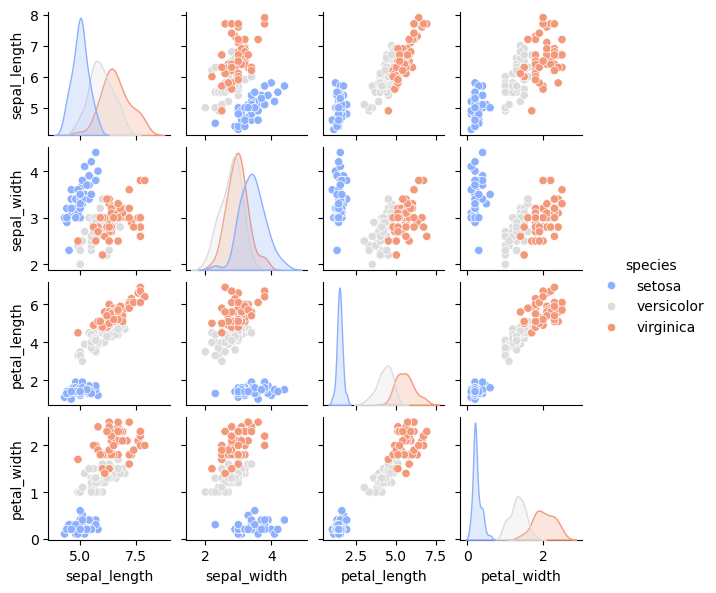

In [7]:
# plt.figure(figsize=(12,5))
f=sns.pairplot(df_full, hue='species', height=1.5, palette='coolwarm')

# plt.show()

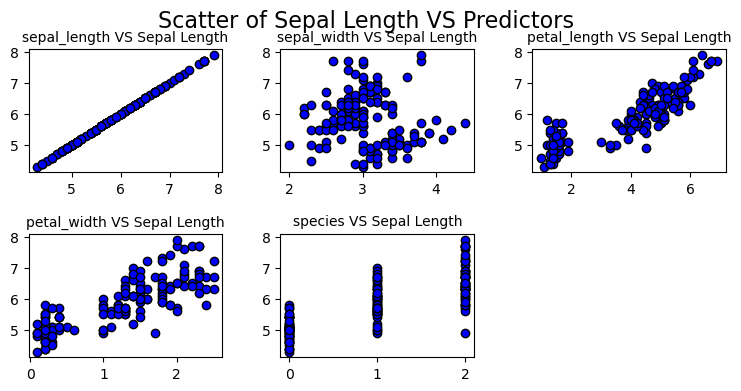

In [8]:
fig, axs = plt.subplots(2,3, figsize=(9,4))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle("Scatter of Sepal Length VS Predictors", fontsize=16)
axs = axs.ravel()

for index, column in enumerate(df.columns):
    axs[index].set_title(f"{column} VS Sepal Length", fontsize=10)
    axs[index].scatter(x=df[column], y=df["sepal_length"], color='blue', edgecolor='k')

for ax in axs[len(df.columns):]:
    ax.set_visible(False)

plt.show()

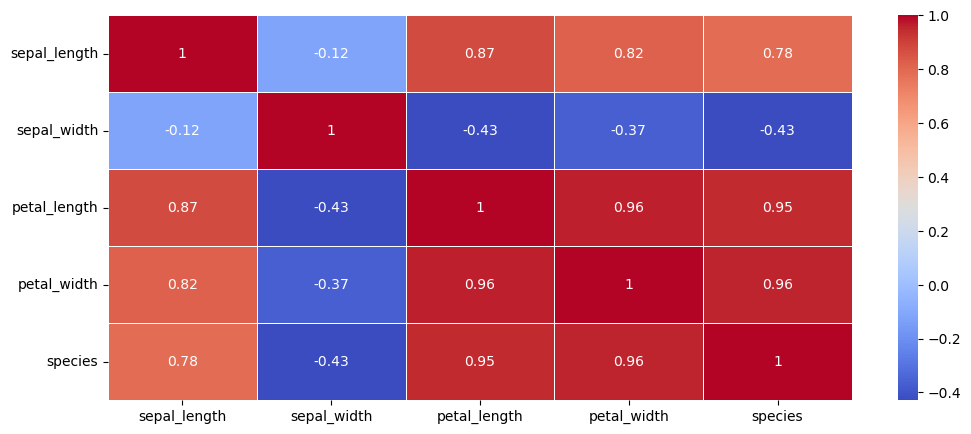

In [9]:
matrix = df.corr()
plt.figure(figsize=(12, 5))
sns.heatmap(matrix, cmap='coolwarm', fmt='.2g', annot=True, linewidth=0.5)

plt.show()

In [10]:
model = LinearRegression()

In [11]:
y = df['sepal_length']
X = np.array(df['petal_width'])
X = X.reshape(-1,1) #Reshape X to a two-dimensional array
X.shape

(150, 1)

In [12]:
model.fit(X,y)
model

LinearRegression()

In [13]:
print('Intercept:', round(model.intercept_, 2))
print('Slope:', round(model.coef_[0], 2))

Intercept: 4.78
Slope: 0.89


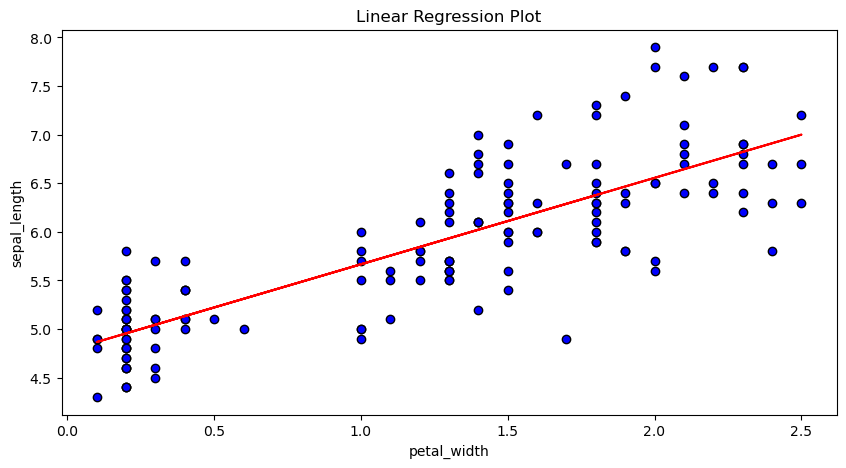

In [14]:
y_pred = model.predict(X)

plt.figure(figsize=(10,5))
plt.scatter(X, y, color='blue', edgecolor='k')
plt.plot(X, y_pred, color='red')
plt.title('Linear Regression Plot')
plt.xlabel('petal_width')
plt.ylabel('sepal_length')

plt.show()

# Gaussian Naive Bayes Classification Model

In [15]:
# Select an appropriate class of model by importing the estimator class from Scikit-Learn.
from sklearn.naive_bayes import GaussianNB

# Select the model hyperparameters by creating new object values from this class.
model = GaussianNB()

# Arrange data into features matrix and target vector.
X = df.drop('species', axis=1)
y = df['species']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=40, test_size=0.2)

# Fit the model by calling the fit() method of the model instance.
model.fit(X_train, y_train)


# Apply the model to new data. Use predict() for supervised learning.
y_pred = model.predict(X_test)

# Check model accuracy
from sklearn.metrics import accuracy_score

print('Accuracy Score:', accuracy_score(y_test, y_pred))

Accuracy Score: 1.0


# Principal Component Analysis(PCA)

In [16]:
# Select an appropriate class of model by importing the estimator class from Scikit-Learn.
from sklearn.decomposition import PCA

# Select the model hyperparameters by creating new object values from this class.
# Hyperparameter here is the number of components which is 2
model = PCA(n_components=2)

# Arrange data into features matrix and target vector.
# Already done earlier

# Fit the model by calling the fit() method of the model instance.
model.fit(X) # y is not specified here


# Apply the model to new data. Use transform() for unsupervised learning.
y_trans = model.transform(X)

pca = pd.DataFrame(y_trans, columns=['PCA_1', 'PCA_2'])
# pca = pd.concat([df, pca], axis=1)
df[['PCA_1', 'PCA_2']] = pca[['PCA_1', 'PCA_2']]
df

,sepal_length,sepal_width,petal_length,petal_width,species,PCA_1,PCA_2
0,5.1,3.5,1.4,0.2,0,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,-2.728717,0.326755
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,1.944110,0.187532
146,6.3,2.5,5.0,1.9,2,1.527167,-0.375317
147,6.5,3.0,5.2,2.0,2,1.764346,0.078859
148,6.2,3.4,5.4,2.3,2,1.900942,0.116628


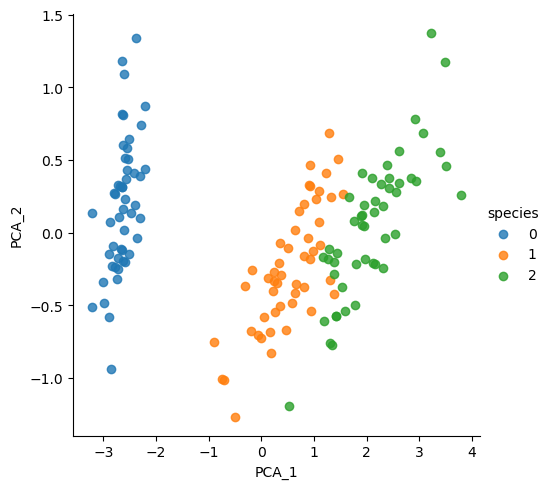

In [17]:
# Plot the results
sns.lmplot(x="PCA_1", y="PCA_2", hue='species', data=df, fit_reg=False)

# Clustering

In [18]:
# Select an appropriate class of model by importing the estimator class from Scikit-Learn.
from sklearn.mixture import GaussianMixture as GMM

# Select the model hyperparameters by creating new object values from this class.
# Hyperparameter here are the number of components which is 3 and covariance_type which is set to 'full'
model = GMM(n_components=3, covariance_type='full')

# Arrange data into features matrix and target vector.
X_full = df_full.drop('species', axis=1)
y_full = df_full['species']

# Fit the model by calling the fit() method of the model instance.
model.fit(X) # y is not specified here


# Apply the model to new data. Use transform()/predict() for unsupervised learning.
y_pred = model.predict(X)

# Add cluster labels to dataFrame
df_full['cluster'] = y_pred
df_full[['PCA_1', 'PCA_2']] = pca[['PCA_1', 'PCA_2']]
df_full

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,sepal_length,sepal_width,petal_length,petal_width,species,cluster,PCA_1,PCA_2
0,5.1,3.5,1.4,0.2,setosa,0,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,setosa,0,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,setosa,0,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,setosa,0,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,setosa,0,-2.728717,0.326755
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2,1.944110,0.187532
146,6.3,2.5,5.0,1.9,virginica,2,1.527167,-0.375317
147,6.5,3.0,5.2,2.0,virginica,2,1.764346,0.078859
148,6.2,3.4,5.4,2.3,virginica,2,1.900942,0.116628


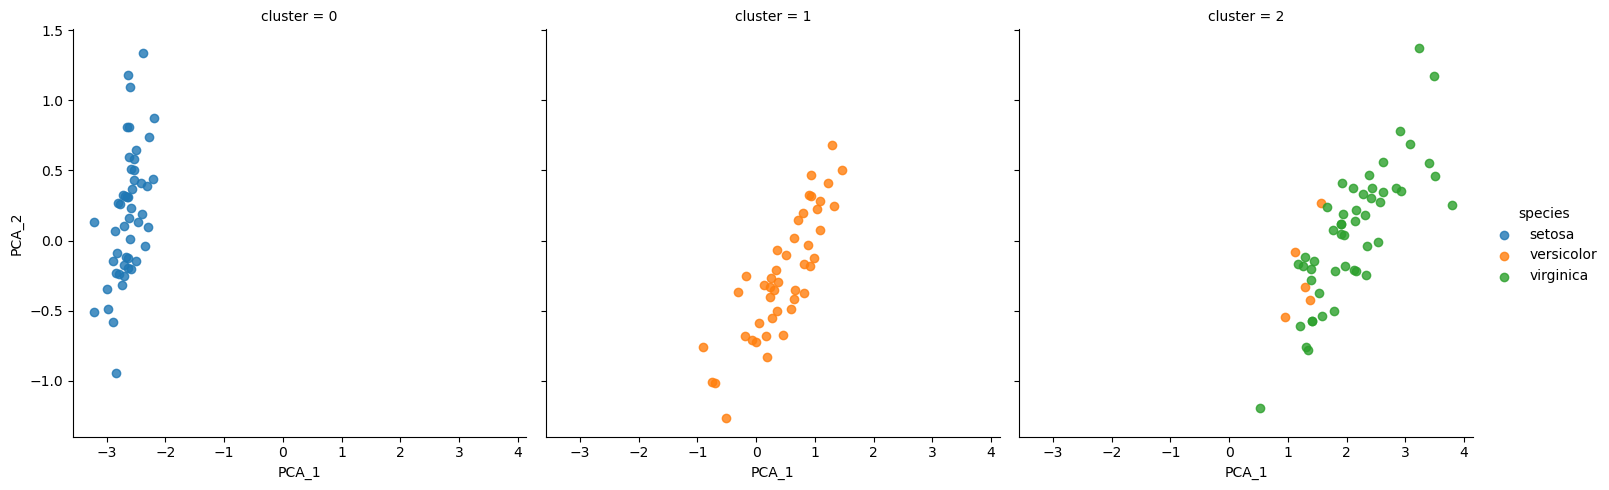

In [19]:
# Plot the result
sns.lmplot(x="PCA_1", y="PCA_2", data=df_full, hue='species', col='cluster', fit_reg=False)

# Exploring Hand Written Digits

(1797, 8, 8)


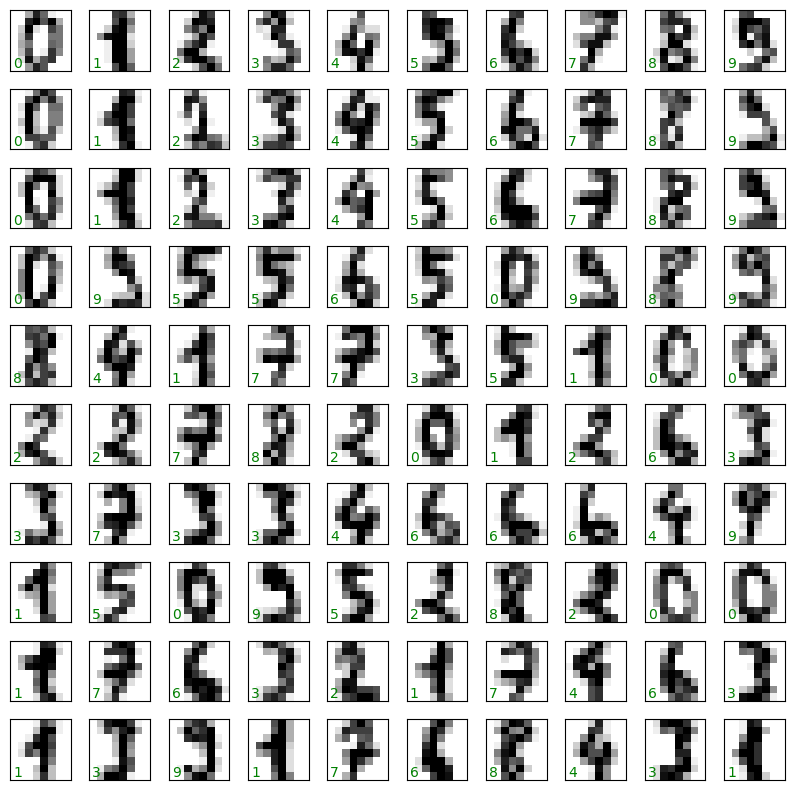

In [20]:
# import the data
from sklearn.datasets import load_digits

df_digits = load_digits()
print(df_digits.images.shape)


fig, axes = plt.subplots(10, 10, figsize=(10,10), subplot_kw={'xticks':[], 'yticks':[]})
fig.subplots_adjust(hspace=0.3, wspace=0.3)
# axs = axs.ravel()

for index, ax in enumerate(axes.flat):
    ax.imshow(df_digits.images[index], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(df_digits.target[index]), transform=ax.transAxes, color='green')

plt.show()

In [21]:
# Our Features
X = df_digits.data
y = df_digits.target

print('X:', X.shape)
print('y:', y.shape)

X: (1797, 64)
y: (1797,)


(1797, 2)


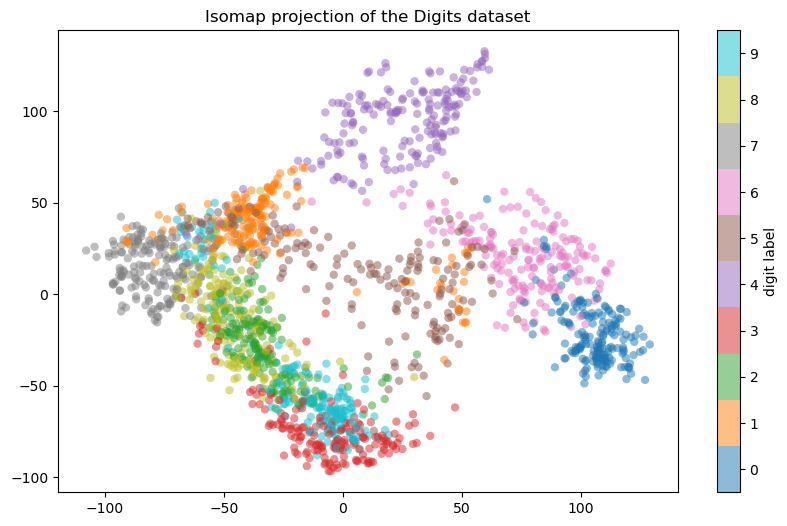

In [22]:
from sklearn.manifold import Isomap

iso = Isomap(n_components=2, n_neighbors=10)
iso.fit(df_digits.data)
df_transform = iso.transform(df_digits.data)

print(df_transform.shape) 

# Visualize the embedding
cmap = plt.colormaps['tab10'] 
plt.figure(figsize=(10, 6))
plt.scatter(
    df_transform[:, 0], df_transform[:, 1],
    c=df_digits.target,
    edgecolor='none',
    alpha=0.5,
    cmap=cmap
)
plt.colorbar(label='digit label', ticks=range(10))
plt.clim(-0.5, 9.5)
plt.title("Isomap projection of the Digits dataset")
plt.show()

# Classification Model on Digits

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print('Accuracy Score:', accuracy_score(y_test, y_pred))

Accuracy Score: 0.825


Text(113.9222222222222, 0.5, 'true value')

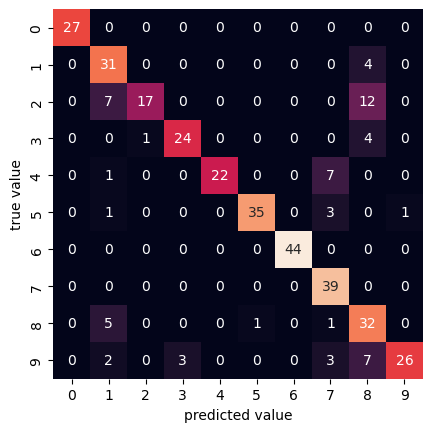

In [24]:
# Plot the confusion matrix
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_test, y_pred)

sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted value')
plt.ylabel('true value')

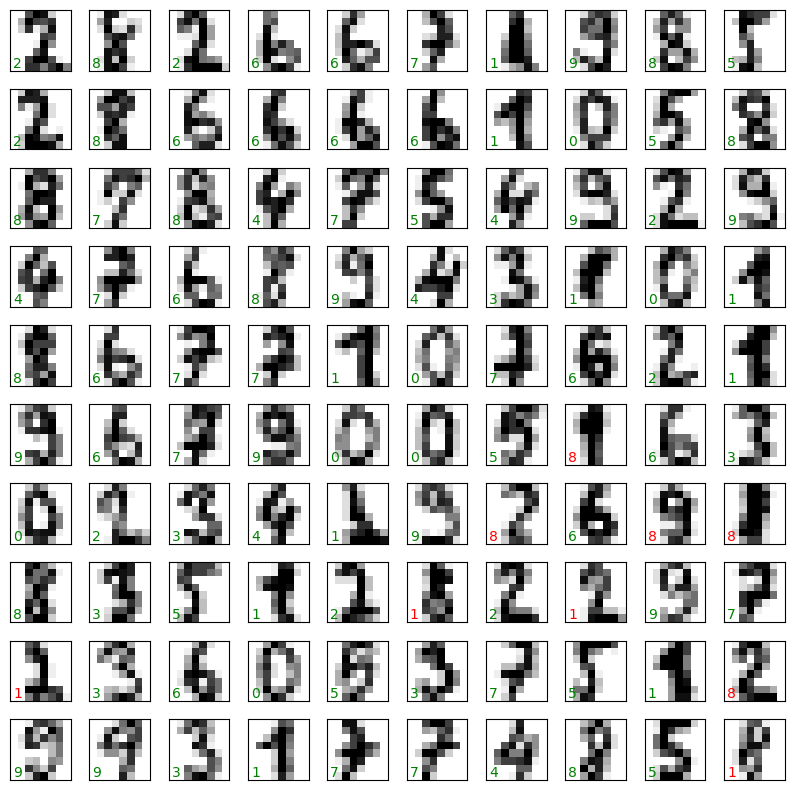

In [25]:
fig, axes = plt.subplots(10, 10, figsize=(10,10), subplot_kw={'xticks':[], 'yticks':[]})
fig.subplots_adjust(hspace=0.3, wspace=0.3)

test_images = X_test.reshape(-1, 8, 8)

for index, ax in enumerate(axes.flat):
    ax.imshow(test_images[index], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(y_pred[index]), transform=ax.transAxes, 
            color='green' if (y_test[index] == y_pred[index]) else 'red')

plt.show()

In [26]:
np?

Type:        module
String form: <module 'numpy' from 'C:\\Users\\User\\anaconda3\\Lib\\site-packages\\numpy\\__init__.py'>
File:        c:\users\user\anaconda3\lib\site-packages\numpy\__init__.py
Docstring:  
NumPy
=====

Provides
  1. An array object of arbitrary homogeneous items
  2. Fast mathematical operations over arrays
  3. Linear Algebra, Fourier Transforms, Random Number Generation

How to use the documentation
----------------------------
Documentation is available in two forms: docstrings provided
with the code, and a loose standing reference guide, available from
`the NumPy homepage <https://numpy.org>`_.

We recommend exploring the docstrings using
`IPython <https://ipython.org>`_, an advanced Python shell with
TAB-completion and introspection capabilities.  See below for further
instructions.

The docstring examples assume that `numpy` has been imported as ``np``::

  >>> import numpy as np

Code snippets are indicated by three greater-than signs::

  >>> x = 42
  >>> x